In [321]:
from pathlib import Path
import sys

from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    if "IPython.extensions.autoreload" not in ip.extension_manager.loaded:
        ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "lif_utils.py").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import torch
import snntorch as snn
import matplotlib.pyplot as plt

from src import lif_utils as lu






Now we want to test the buffers with 1-D moving objects

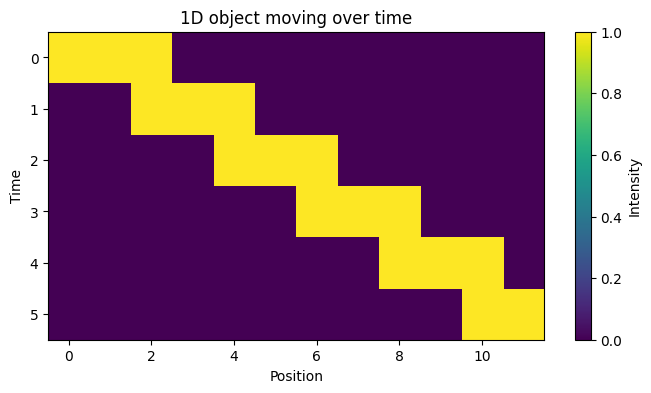

In [126]:
frames = lu.make_moving_1d_object()

plt.figure(figsize=(8, 4))
plt.imshow(frames, aspect="auto")
plt.xlabel("Position")
plt.ylabel("Time")
plt.title("1D object moving over time")
plt.colorbar(label="Intensity")
plt.show()







Each LIF neuron corresponds to 1 spatial position

frames shape: torch.Size([6, 12])
spikes shape: torch.Size([6, 12])
membrane shape: torch.Size([6, 12])


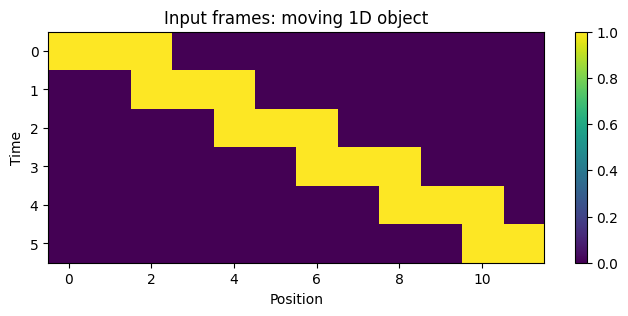

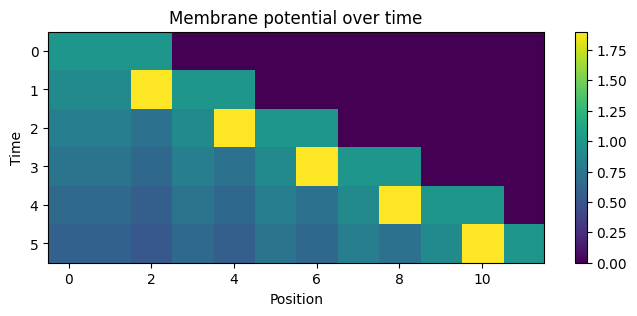

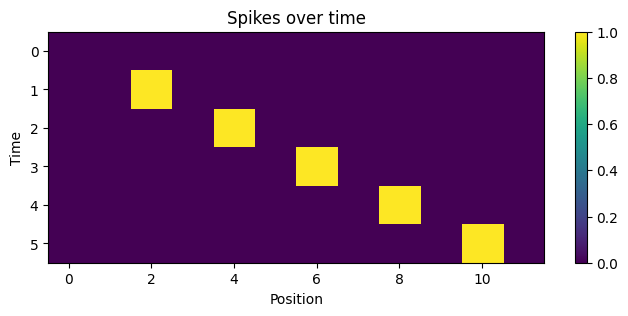

In [127]:
# Make moving 1D object
frames = lu.make_moving_1d_object(
    length=12,
    object_width=3,
    steps=6,
    speed=2,
    intensity=1,
)

beta = 0.9
lif = snn.Leaky(beta=beta)

# One membrane value per spatial position
mem = torch.zeros(12)

spk_rec = []
mem_rec = []

for t in range(frames.shape[0]):
    current = frames[t]

    spk, mem = lif(current, mem)

    spk_rec.append(spk.clone())
    mem_rec.append(mem.clone())

spk_rec = torch.stack(spk_rec)
mem_rec = torch.stack(mem_rec)

print("frames shape:", frames.shape)
print("spikes shape:", spk_rec.shape)
print("membrane shape:", mem_rec.shape)

plt.figure(figsize=(8, 3))
plt.imshow(frames, aspect="auto")
plt.title("Input frames: moving 1D object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(mem_rec.detach(), aspect="auto")
plt.title("Membrane potential over time")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(spk_rec.detach(), aspect="auto")
plt.title("Spikes over time")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()





Analyzibng position 2

In [128]:
frames = lu.make_moving_1d_object(
    length=12,
    object_width=3,
    steps=6,
    speed=2,
    intensity=1,
)

beta = 0.9
lif = snn.Leaky(beta=beta)
mem = torch.zeros(12)

for t in range(frames.shape[0]):
    current = frames[t]
    spk, mem = lif(current, mem)

    print(f"t={t}")
    print("current[2]:", current[2].item())
    print("spk[2]:    ", spk[2].item())
    print("mem[2]:    ", mem[2].item())
    print()





t=0
current[2]: 1.0
spk[2]:     0.0
mem[2]:     1.0

t=1
current[2]: 1.0
spk[2]:     1.0
mem[2]:     1.899999976158142

t=2
current[2]: 0.0
spk[2]:     0.0
mem[2]:     0.7099999189376831

t=3
current[2]: 0.0
spk[2]:     0.0
mem[2]:     0.6389999389648438

t=4
current[2]: 0.0
spk[2]:     0.0
mem[2]:     0.5750999450683594

t=5
current[2]: 0.0
spk[2]:     0.0
mem[2]:     0.5175899267196655



In [129]:
lif = snn.Leaky(beta=0.9)
print("reset mechanism:", lif.reset_mechanism)
print("threshold:", lif.threshold)





reset mechanism: subtract
threshold: tensor(1.)


In [130]:
for reset in ["subtract", "zero", "none"]:
    print("\nreset:", reset)

    lif = snn.Leaky(beta=0.9, reset_mechanism=reset)
    mem = torch.zeros(1)

    for t, x in enumerate([1.01, 1.01, 1.01]):
        spk, mem = lif(torch.tensor([x]), mem)
        print(f"t={t}, input={x}, spike={spk.item()}, mem={mem.item():.3f}")






reset: subtract
t=0, input=1.01, spike=1.0, mem=1.010
t=1, input=1.01, spike=0.0, mem=0.919
t=2, input=1.01, spike=1.0, mem=1.837

reset: zero
t=0, input=1.01, spike=1.0, mem=1.010
t=1, input=1.01, spike=1.0, mem=1.010
t=2, input=1.01, spike=1.0, mem=1.010

reset: none
t=0, input=1.01, spike=1.0, mem=1.010
t=1, input=1.01, spike=1.0, mem=1.919
t=2, input=1.01, spike=1.0, mem=2.737


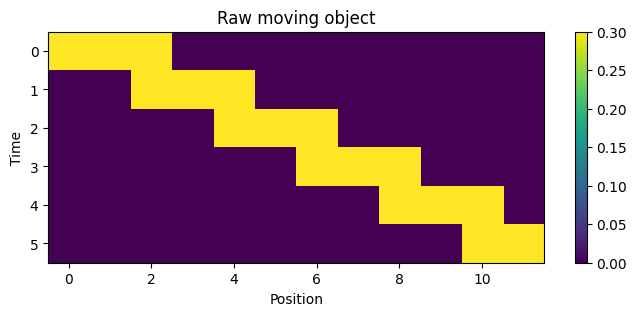

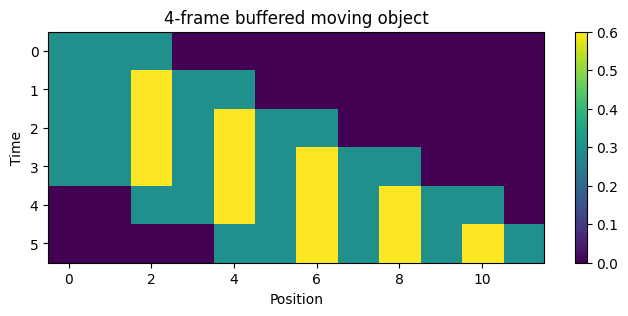

In [131]:
frames = lu.make_moving_1d_object(
    length=12,
    object_width=3,
    steps=6,
    speed=2,
    intensity=0.3,
)

buffered_frames = lu.apply_frame_buffer(frames, buffer_size=4)

plt.figure(figsize=(8, 3))
plt.imshow(frames, aspect="auto")
plt.title("Raw moving object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(buffered_frames, aspect="auto")
plt.title("4-frame buffered moving object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()





In [132]:
spk_raw, mem_raw = lu.run_lif_layer(frames, beta=0.9)
spk_buf, mem_buf = lu.run_lif_layer(buffered_frames, beta=0.9)





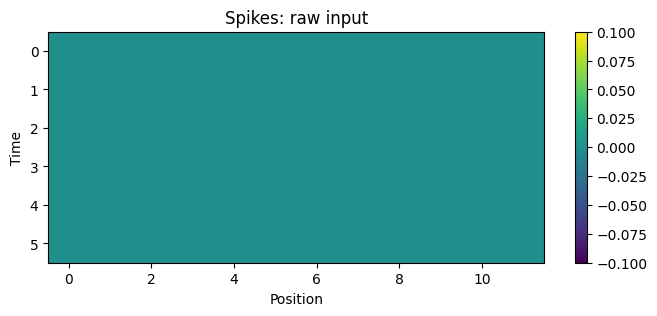

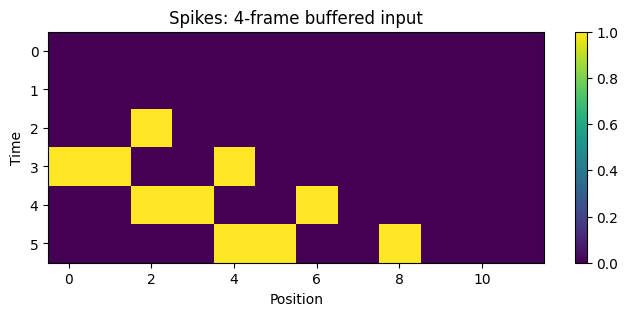

In [133]:
plt.figure(figsize=(8, 3))
plt.imshow(spk_raw.detach(), aspect="auto")
plt.title("Spikes: raw input")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(spk_buf.detach(), aspect="auto")
plt.title("Spikes: 4-frame buffered input")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()





3 problems with this approach 
1) Different positions of the same object spike at different times
2) Same position can spike multiple times
3) Large delay 

In [134]:
positions_to_debug = [0, 1, 2]

for pos in positions_to_debug:
    print(f"\nPosition {pos}")
    print("t | raw | buffered | mem | spike")
    print("--|-----|----------|-----|------")

    for t in range(frames.shape[0]):
        print(
            f"{t:1d} | "
            f"{frames[t, pos].item():.2f} | "
            f"{buffered_frames[t, pos].item():.2f} | "
            f"{mem_buf[t, pos].item():.3f} | "
            f"{spk_buf[t, pos].item():.0f}"
        )






Position 0
t | raw | buffered | mem | spike
--|-----|----------|-----|------
0 | 0.30 | 0.30 | 0.300 | 0
1 | 0.00 | 0.30 | 0.570 | 0
2 | 0.00 | 0.30 | 0.813 | 0
3 | 0.00 | 0.30 | 1.032 | 1
4 | 0.00 | 0.00 | -0.071 | 0
5 | 0.00 | 0.00 | -0.064 | 0

Position 1
t | raw | buffered | mem | spike
--|-----|----------|-----|------
0 | 0.30 | 0.30 | 0.300 | 0
1 | 0.00 | 0.30 | 0.570 | 0
2 | 0.00 | 0.30 | 0.813 | 0
3 | 0.00 | 0.30 | 1.032 | 1
4 | 0.00 | 0.00 | -0.071 | 0
5 | 0.00 | 0.00 | -0.064 | 0

Position 2
t | raw | buffered | mem | spike
--|-----|----------|-----|------
0 | 0.30 | 0.30 | 0.300 | 0
1 | 0.30 | 0.60 | 0.870 | 0
2 | 0.00 | 0.60 | 1.383 | 1
3 | 0.00 | 0.60 | 0.845 | 0
4 | 0.00 | 0.30 | 1.060 | 1
5 | 0.00 | 0.00 | -0.046 | 0


First I will try a decay4 buffer

In [135]:
buffered_frames_decay = lu.apply_decay_frame_buffer(
    frames,
    buffer_size=4,
    decay=0.7,
)

spk_decay, mem_decay = lu.run_lif_layer(buffered_frames_decay, beta=0.9)





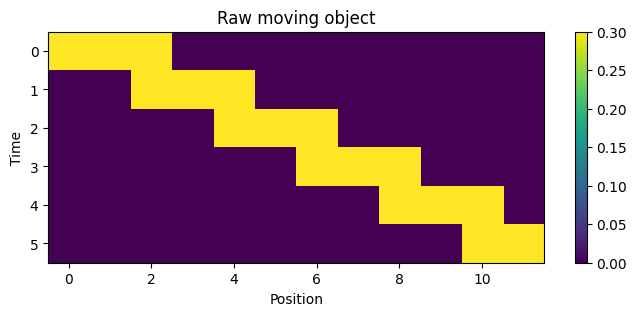

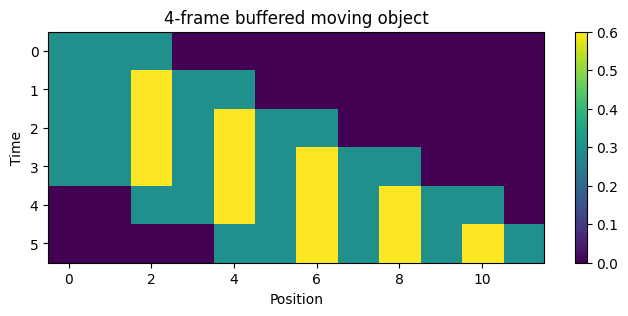

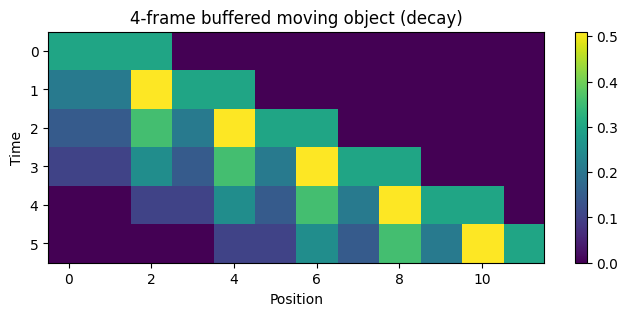

In [136]:
plt.figure(figsize=(8, 3))
plt.imshow(frames, aspect="auto")
plt.title("Raw moving object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(buffered_frames, aspect="auto")
plt.title("4-frame buffered moving object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(buffered_frames_decay, aspect="auto")
plt.title("4-frame buffered moving object (decay)")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()





In [137]:
spk_raw, mem_raw = lu.run_lif_layer(frames, beta=0.9)
spk_buf, mem_buf = lu.run_lif_layer(buffered_frames, beta=0.9)
spk_decay, mem_decay = lu.run_lif_layer(buffered_frames_decay, beta=0.9)





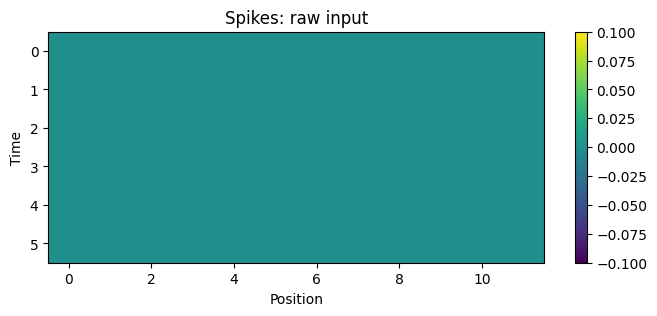

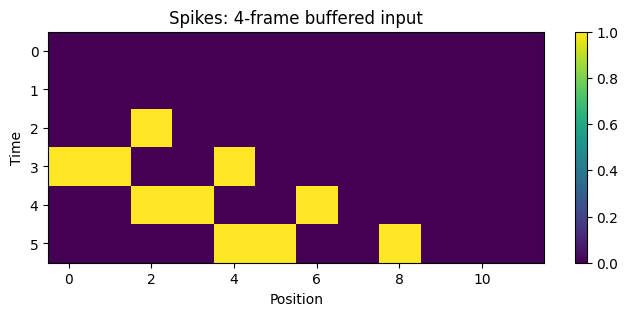

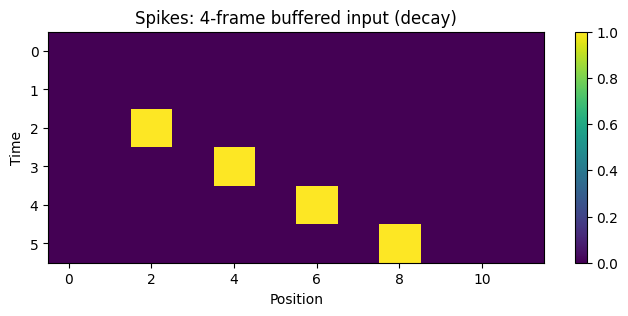

In [138]:
plt.figure(figsize=(8, 3))
plt.imshow(spk_raw.detach(), aspect="auto")
plt.title("Spikes: raw input")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(spk_buf.detach(), aspect="auto")
plt.title("Spikes: 4-frame buffered input")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(spk_decay.detach(), aspect="auto")
plt.title("Spikes: 4-frame buffered input (decay)")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()





In [139]:
positions_to_debug = [0, 1, 2]


for pos in positions_to_debug:
    print(f"\nPosition {pos}")
    print(
        "t | raw | sum4 | mem_sum4 | spk_sum4 | decay4 | mem_decay4 | spk_decay4"
    )
    print(
        "--|-----|------|----------|----------|--------|------------|-----------"
    )

    for t in range(frames.shape[0]):
        print(
            f"{t:1d} | "
            f"{frames[t, pos].item():.2f} | "
            f"{buffered_frames[t, pos].item():.2f} | "
            f"{mem_buf[t, pos].item():8.3f} | "
            f"{spk_buf[t, pos].item():8.0f} | "
            f"{buffered_frames_decay[t, pos].item():6.2f} | "
            f"{mem_decay[t, pos].item():10.3f} | "
            f"{spk_decay[t, pos].item():9.0f}"
        )






Position 0
t | raw | sum4 | mem_sum4 | spk_sum4 | decay4 | mem_decay4 | spk_decay4
--|-----|------|----------|----------|--------|------------|-----------
0 | 0.30 | 0.30 |    0.300 |        0 |   0.30 |      0.300 |         0
1 | 0.00 | 0.30 |    0.570 |        0 |   0.21 |      0.480 |         0
2 | 0.00 | 0.30 |    0.813 |        0 |   0.15 |      0.579 |         0
3 | 0.00 | 0.30 |    1.032 |        1 |   0.10 |      0.624 |         0
4 | 0.00 | 0.00 |   -0.071 |        0 |   0.00 |      0.562 |         0
5 | 0.00 | 0.00 |   -0.064 |        0 |   0.00 |      0.505 |         0

Position 1
t | raw | sum4 | mem_sum4 | spk_sum4 | decay4 | mem_decay4 | spk_decay4
--|-----|------|----------|----------|--------|------------|-----------
0 | 0.30 | 0.30 |    0.300 |        0 |   0.30 |      0.300 |         0
1 | 0.00 | 0.30 |    0.570 |        0 |   0.21 |      0.480 |         0
2 | 0.00 | 0.30 |    0.813 |        0 |   0.15 |      0.579 |         0
3 | 0.00 | 0.30 |    1.032 |        1 | 

We fix stale response but now a new problem:
Only an object seen twice is reognized

A hard 4-frame sum buffer increases sensitivity but creates stale delayed spikes. A 4-frame decayed buffer suppresses stale single-frame evidence while preserving detection at positions that receive repeated evidence.

In [140]:
summaries = []

summaries.append(lu.summarize_spikes(frames, spk_raw, "raw"))
summaries.append(lu.summarize_spikes(frames, spk_buf, "sum4"))
summaries.append(lu.summarize_spikes(frames, spk_decay, "decay4"))

for s in summaries:
    print(s)





{'method': 'raw', 'total_spikes': 0, 'stale_spikes': 0, 'duplicate_positions': 0, 'first_spike_time': None}
{'method': 'sum4', 'total_spikes': 10, 'stale_spikes': 10, 'duplicate_positions': 2, 'first_spike_time': 2}
{'method': 'decay4', 'total_spikes': 4, 'stale_spikes': 4, 'duplicate_positions': 0, 'first_spike_time': 2}


Need a better summarization of the spikes

In [141]:
delay_summaries = [
    lu.summarize_local_spike_delays(frames, spk_raw, "raw"),
    lu.summarize_local_spike_delays(frames, spk_buf, "sum4"),
    lu.summarize_local_spike_delays(frames, spk_decay, "decay4"),
]

for summary in delay_summaries:
    print(summary["method"])
    print("num_spikes:", summary["num_spikes"])
    print("mean_delay:", summary["mean_delay"])
    print("max_delay:", summary["max_delay"])
    print("events:", summary["events"])
    print()





raw
num_spikes: 0
mean_delay: None
max_delay: None
events: []

sum4
num_spikes: 10
mean_delay: 2.2
max_delay: 3
events: [{'time': 2, 'position': 2, 'delay': 1}, {'time': 3, 'position': 0, 'delay': 3}, {'time': 3, 'position': 1, 'delay': 3}, {'time': 3, 'position': 4, 'delay': 1}, {'time': 4, 'position': 2, 'delay': 3}, {'time': 4, 'position': 3, 'delay': 3}, {'time': 4, 'position': 6, 'delay': 1}, {'time': 5, 'position': 4, 'delay': 3}, {'time': 5, 'position': 5, 'delay': 3}, {'time': 5, 'position': 8, 'delay': 1}]

decay4
num_spikes: 4
mean_delay: 1.0
max_delay: 1
events: [{'time': 2, 'position': 2, 'delay': 1}, {'time': 3, 'position': 4, 'delay': 1}, {'time': 4, 'position': 6, 'delay': 1}, {'time': 5, 'position': 8, 'delay': 1}]



In [ ]:
spatial_summaries = [
    lu.summarize_spatial_error(frames, spk_raw, "raw"),
    lu.summarize_spatial_error(frames, spk_buf, "sum4"),
    lu.summarize_spatial_error(frames, spk_decay, "decay4"),
]

for summary in spatial_summaries:
    print(summary["method"])
    print("num_spikes:", summary["num_spikes"])
    print("mean_spatial_error:", summary["mean_spatial_error"])
    print("max_spatial_error:", summary["max_spatial_error"])
    print("events:", summary["events"])
    print()





Now will try different object speeds:


########################################################

SPEED=1

##########################################################

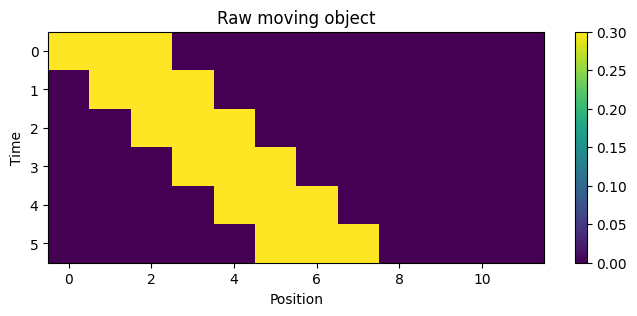

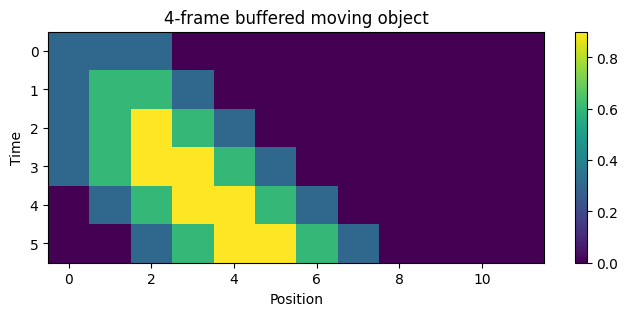

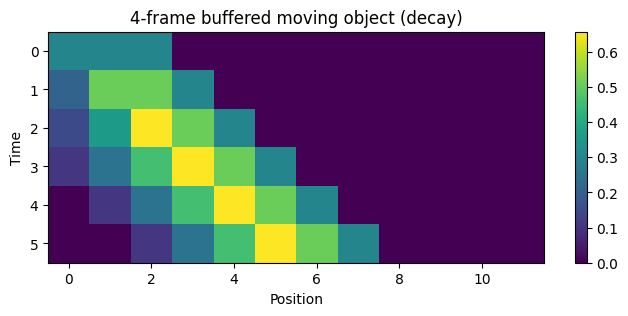

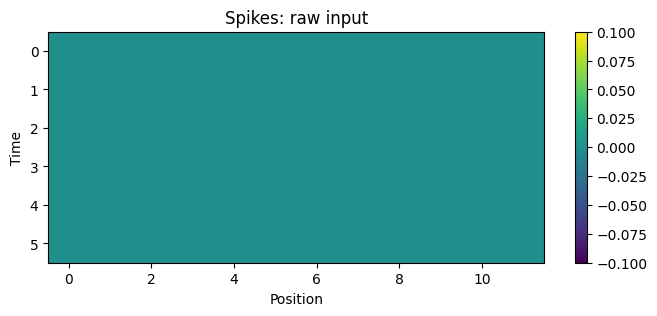

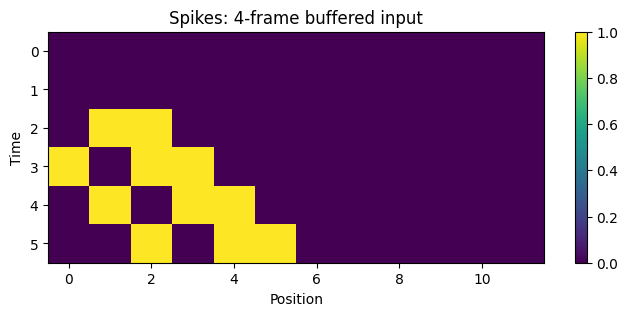

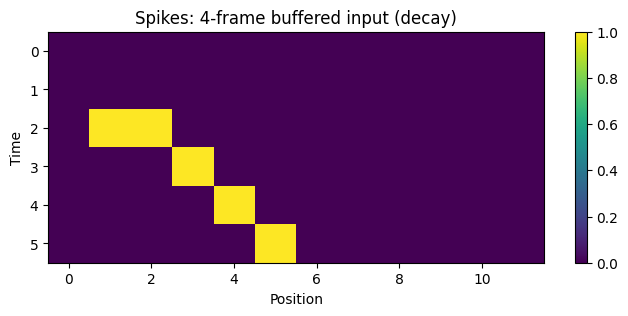

In [156]:
frames = lu.make_moving_1d_object(
    length=12,
    object_width=3,
    steps=6,
    speed=1,
    intensity=0.3,
)

buffered_frames = lu.apply_frame_buffer(frames, buffer_size=4)
buffered_frames_decay = lu.apply_decay_frame_buffer(
    frames,
    buffer_size=4,
    decay=0.7,
)

plt.figure(figsize=(8, 3))
plt.imshow(frames, aspect="auto")
plt.title("Raw moving object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(buffered_frames, aspect="auto")
plt.title("4-frame buffered moving object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(buffered_frames_decay, aspect="auto")
plt.title("4-frame buffered moving object (decay)")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

spk_raw, mem_raw = lu.run_lif_layer(frames, beta=0.9)
spk_buf, mem_buf = lu.run_lif_layer(buffered_frames, beta=0.9)
spk_decay, mem_decay = lu.run_lif_layer(buffered_frames_decay, beta=0.9)

plt.figure(figsize=(8, 3))
plt.imshow(spk_raw.detach(), aspect="auto")
plt.title("Spikes: raw input")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(spk_buf.detach(), aspect="auto")
plt.title("Spikes: 4-frame buffered input")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(spk_decay.detach(), aspect="auto")
plt.title("Spikes: 4-frame buffered input (decay)")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()





In [157]:
delay_summaries = [
    lu.summarize_local_spike_delays(frames, spk_raw, "raw"),
    lu.summarize_local_spike_delays(frames, spk_buf, "sum4"),
    lu.summarize_local_spike_delays(frames, spk_decay, "decay4"),
]

for summary in delay_summaries:
    print(summary["method"])
    print("num_spikes:", summary["num_spikes"])
    print("mean_delay:", summary["mean_delay"])
    print("max_delay:", summary["max_delay"])
    print("events:", summary["events"])
    print()





raw
num_spikes: 0
mean_delay: None
max_delay: None
events: []

sum4
num_spikes: 11
mean_delay: 1.1818181818181819
max_delay: 3
events: [{'time': 2, 'position': 1, 'delay': 1}, {'time': 2, 'position': 2, 'delay': 0}, {'time': 3, 'position': 0, 'delay': 3}, {'time': 3, 'position': 2, 'delay': 1}, {'time': 3, 'position': 3, 'delay': 0}, {'time': 4, 'position': 1, 'delay': 3}, {'time': 4, 'position': 3, 'delay': 1}, {'time': 4, 'position': 4, 'delay': 0}, {'time': 5, 'position': 2, 'delay': 3}, {'time': 5, 'position': 4, 'delay': 1}, {'time': 5, 'position': 5, 'delay': 0}]

decay4
num_spikes: 5
mean_delay: 0.2
max_delay: 1
events: [{'time': 2, 'position': 1, 'delay': 1}, {'time': 2, 'position': 2, 'delay': 0}, {'time': 3, 'position': 3, 'delay': 0}, {'time': 4, 'position': 4, 'delay': 0}, {'time': 5, 'position': 5, 'delay': 0}]



In [158]:
spatial_summaries = [
    lu.summarize_spatial_error(frames, spk_raw, "raw"),
    lu.summarize_spatial_error(frames, spk_buf, "sum4"),
    lu.summarize_spatial_error(frames, spk_decay, "decay4"),
]

for summary in spatial_summaries:
    print(summary["method"])
    print("num_spikes:", summary["num_spikes"])
    print("mean_spatial_error:", summary["mean_spatial_error"])
    print("max_spatial_error:", summary["max_spatial_error"])
    print("events:", summary["events"])
    print()





raw
num_spikes: 0
mean_spatial_error: None
max_spatial_error: None
events: []

sum4
num_spikes: 11
mean_spatial_error: 1.1818181818181819
max_spatial_error: 3
events: [{'time': 2, 'position': 1, 'spatial_error': 1}, {'time': 2, 'position': 2, 'spatial_error': 0}, {'time': 3, 'position': 0, 'spatial_error': 3}, {'time': 3, 'position': 2, 'spatial_error': 1}, {'time': 3, 'position': 3, 'spatial_error': 0}, {'time': 4, 'position': 1, 'spatial_error': 3}, {'time': 4, 'position': 3, 'spatial_error': 1}, {'time': 4, 'position': 4, 'spatial_error': 0}, {'time': 5, 'position': 2, 'spatial_error': 3}, {'time': 5, 'position': 4, 'spatial_error': 1}, {'time': 5, 'position': 5, 'spatial_error': 0}]

decay4
num_spikes: 5
mean_spatial_error: 0.2
max_spatial_error: 1
events: [{'time': 2, 'position': 1, 'spatial_error': 1}, {'time': 2, 'position': 2, 'spatial_error': 0}, {'time': 3, 'position': 3, 'spatial_error': 0}, {'time': 4, 'position': 4, 'spatial_error': 0}, {'time': 5, 'position': 5, 'spatial_

########################################################

SPEED=3

##########################################################

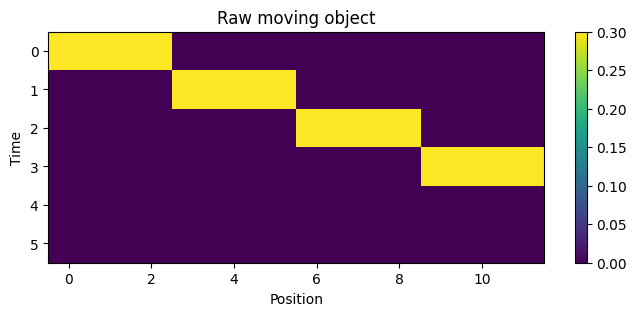

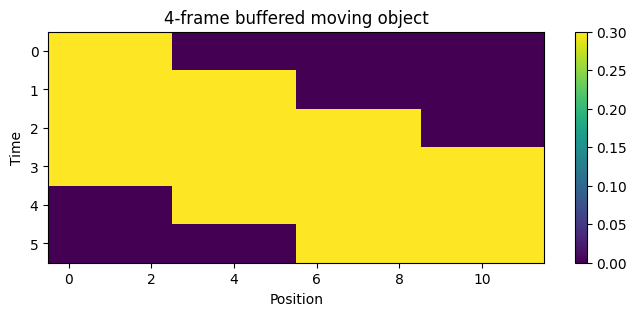

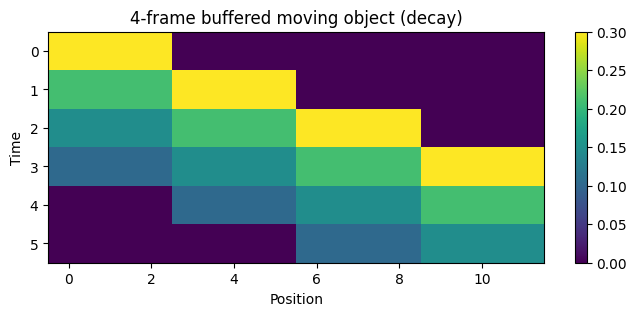

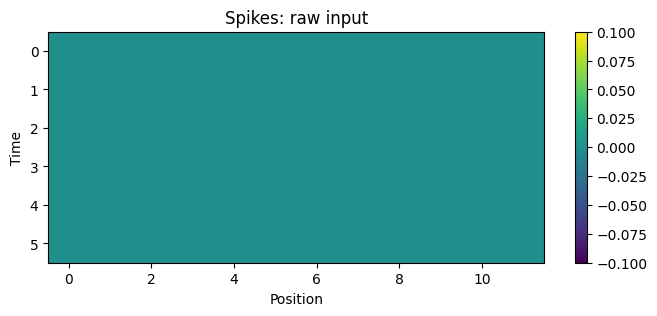

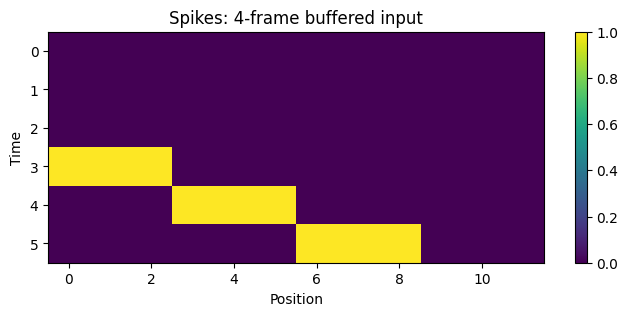

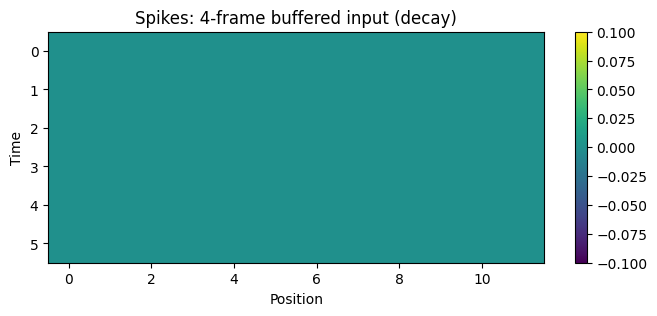

In [159]:
frames = lu.make_moving_1d_object(
    length=12,
    object_width=3,
    steps=6,
    speed=3,
    intensity=0.3,
)

buffered_frames = lu.apply_frame_buffer(frames, buffer_size=4)
buffered_frames_decay = lu.apply_decay_frame_buffer(
    frames,
    buffer_size=4,
    decay=0.7,
)

plt.figure(figsize=(8, 3))
plt.imshow(frames, aspect="auto")
plt.title("Raw moving object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(buffered_frames, aspect="auto")
plt.title("4-frame buffered moving object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(buffered_frames_decay, aspect="auto")
plt.title("4-frame buffered moving object (decay)")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

spk_raw, mem_raw = lu.run_lif_layer(frames, beta=0.9)
spk_buf, mem_buf = lu.run_lif_layer(buffered_frames, beta=0.9)
spk_decay, mem_decay = lu.run_lif_layer(buffered_frames_decay, beta=0.9)

plt.figure(figsize=(8, 3))
plt.imshow(spk_raw.detach(), aspect="auto")
plt.title("Spikes: raw input")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(spk_buf.detach(), aspect="auto")
plt.title("Spikes: 4-frame buffered input")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(spk_decay.detach(), aspect="auto")
plt.title("Spikes: 4-frame buffered input (decay)")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()





In [160]:
delay_summaries = [
    lu.summarize_local_spike_delays(frames, spk_raw, "raw"),
    lu.summarize_local_spike_delays(frames, spk_buf, "sum4"),
    lu.summarize_local_spike_delays(frames, spk_decay, "decay4"),
]

for summary in delay_summaries:
    print(summary["method"])
    print("num_spikes:", summary["num_spikes"])
    print("mean_delay:", summary["mean_delay"])
    print("max_delay:", summary["max_delay"])
    print("events:", summary["events"])
    print()



raw
num_spikes: 0
mean_delay: None
max_delay: None
events: []

sum4
num_spikes: 9
mean_delay: 3.0
max_delay: 3
events: [{'time': 3, 'position': 0, 'delay': 3}, {'time': 3, 'position': 1, 'delay': 3}, {'time': 3, 'position': 2, 'delay': 3}, {'time': 4, 'position': 3, 'delay': 3}, {'time': 4, 'position': 4, 'delay': 3}, {'time': 4, 'position': 5, 'delay': 3}, {'time': 5, 'position': 6, 'delay': 3}, {'time': 5, 'position': 7, 'delay': 3}, {'time': 5, 'position': 8, 'delay': 3}]

decay4
num_spikes: 0
mean_delay: None
max_delay: None
events: []



In [161]:
spatial_summaries = [
    lu.summarize_spatial_error(frames, spk_raw, "raw"),
    lu.summarize_spatial_error(frames, spk_buf, "sum4"),
    lu.summarize_spatial_error(frames, spk_decay, "decay4"),
]

for summary in spatial_summaries:
    print(summary["method"])
    print("num_spikes:", summary["num_spikes"])
    print("mean_spatial_error:", summary["mean_spatial_error"])
    print("max_spatial_error:", summary["max_spatial_error"])
    print("events:", summary["events"])
    print()





raw
num_spikes: 0
mean_spatial_error: None
max_spatial_error: None
events: []

sum4
num_spikes: 9
mean_spatial_error: 8.0
max_spatial_error: 9
events: [{'time': 3, 'position': 0, 'spatial_error': 9}, {'time': 3, 'position': 1, 'spatial_error': 8}, {'time': 3, 'position': 2, 'spatial_error': 7}, {'time': 4, 'position': 3, 'spatial_error': None}, {'time': 4, 'position': 4, 'spatial_error': None}, {'time': 4, 'position': 5, 'spatial_error': None}, {'time': 5, 'position': 6, 'spatial_error': None}, {'time': 5, 'position': 7, 'spatial_error': None}, {'time': 5, 'position': 8, 'spatial_error': None}]

decay4
num_spikes: 0
mean_spatial_error: None
max_spatial_error: None
events: []



Will try a new buffer-type - motion-compensated

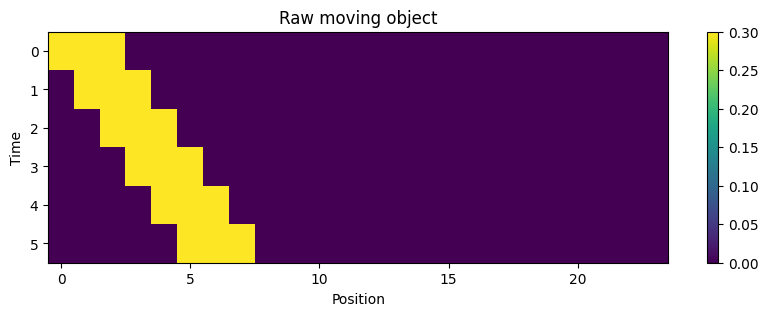

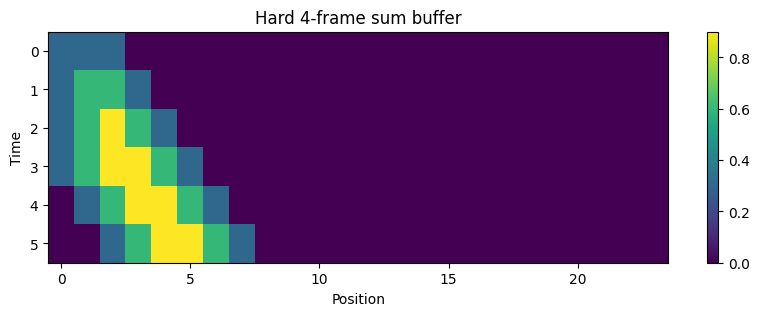

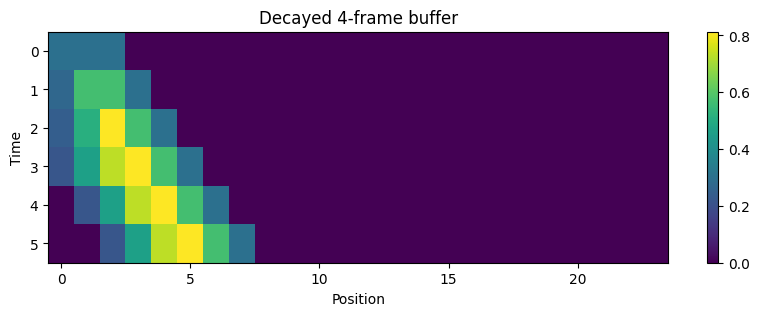

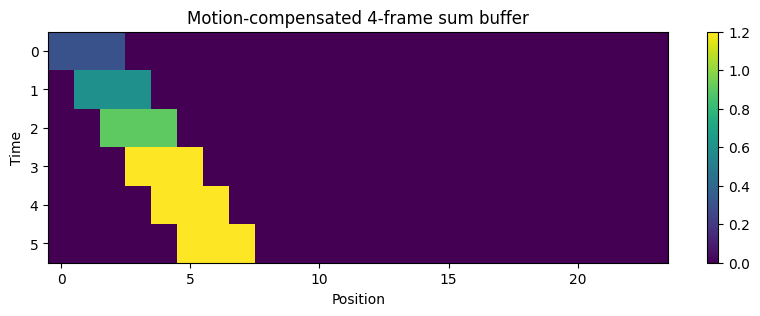

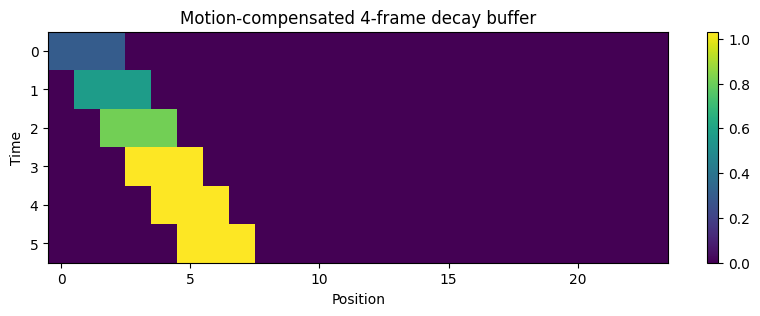

In [316]:
speed = 1

frames = lu.make_moving_1d_object(
    length=24,
    object_width=3,
    steps=6,
    speed=speed,
    intensity=0.3,
)

buffered_frames = lu.apply_frame_buffer(frames, buffer_size=4)
buffered_frames_decay = lu.apply_decay_frame_buffer(
    frames,
    buffer_size=4,
    decay=0.9,
)


buffered_frames_motion = lu.apply_motion_compensated_buffer(
    frames,
    buffer_size=4,
    assumed_speed=speed,
    decay=None,
)

buffered_frames_motion_decay = lu.apply_motion_compensated_buffer(
    frames,
    buffer_size=4,
    assumed_speed=speed,
    decay=0.9,
)


spk_raw, mem_raw = lu.run_lif_layer(frames, beta=0.9)
spk_buf, mem_buf = lu.run_lif_layer(buffered_frames, beta=0.9)
spk_decay, mem_decay = lu.run_lif_layer(buffered_frames_decay, beta=0.9)
spk_motion, mem_motion = lu.run_lif_layer(buffered_frames_motion, beta=0.9)
spk_motion_decay, mem_motion_decay = lu.run_lif_layer(buffered_frames_motion_decay, beta=0.9)

plt.figure(figsize=(10, 3))
plt.imshow(frames, aspect="auto")
plt.title("Raw moving object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 3))
plt.imshow(buffered_frames, aspect="auto")
plt.title("Hard 4-frame sum buffer")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 3))
plt.imshow(buffered_frames_decay, aspect="auto")
plt.title("Decayed 4-frame buffer")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 3))
plt.imshow(buffered_frames_motion, aspect="auto")
plt.title("Motion-compensated 4-frame sum buffer")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 3))
plt.imshow(buffered_frames_motion_decay, aspect="auto")
plt.title("Motion-compensated 4-frame decay buffer")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()





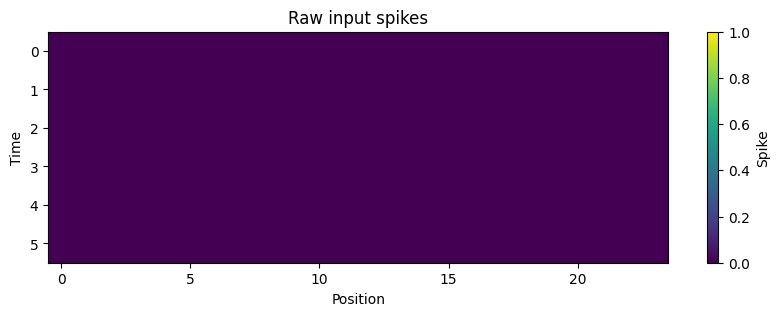

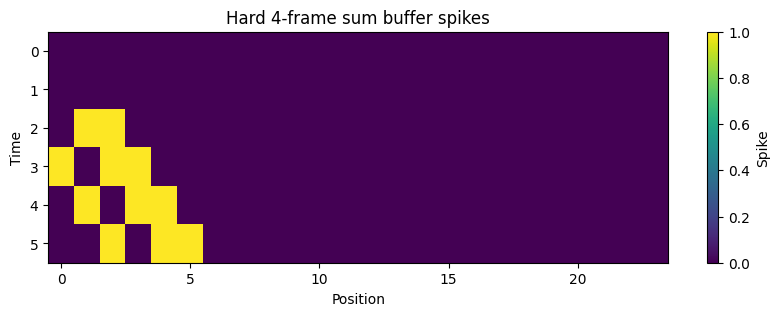

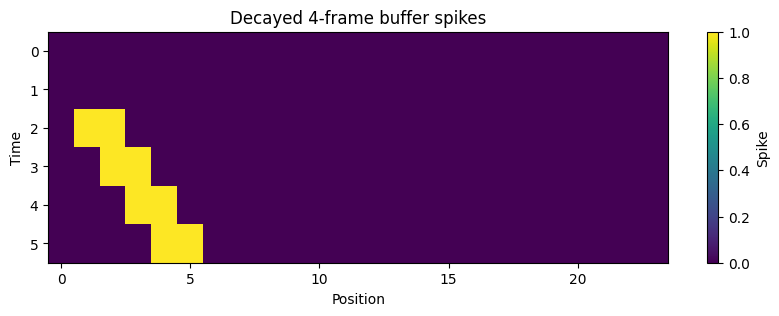

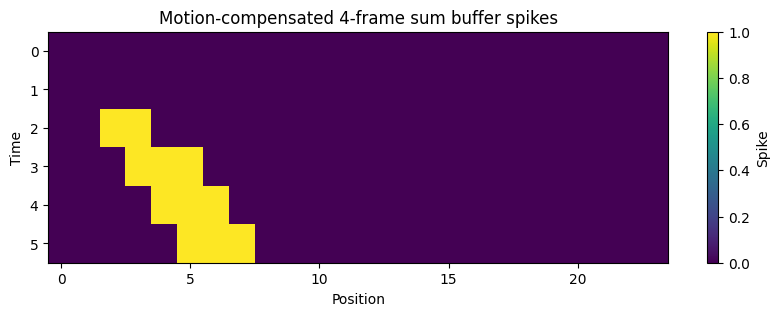

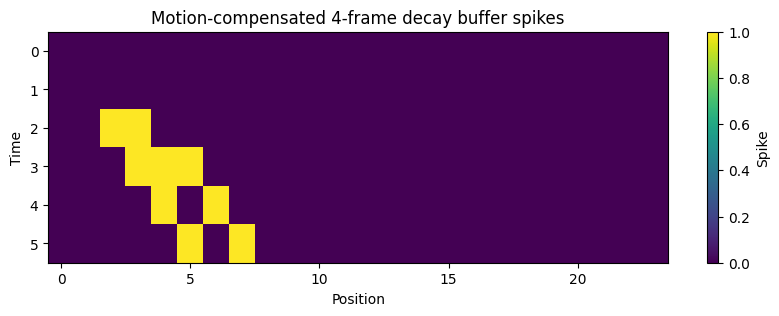

In [317]:
lu.plot_spikes(spk_raw, "Raw input spikes")
lu.plot_spikes(spk_buf, "Hard 4-frame sum buffer spikes")
lu.plot_spikes(spk_decay, "Decayed 4-frame buffer spikes")
lu.plot_spikes(spk_motion, "Motion-compensated 4-frame sum buffer spikes")
lu.plot_spikes(spk_motion_decay, "Motion-compensated 4-frame decay buffer spikes")



In [271]:
spatial_summaries = [
    lu.summarize_spatial_error(frames, spk_raw, "raw"),
    lu.summarize_spatial_error(frames, spk_buf, "sum4"),
    lu.summarize_spatial_error(frames, spk_decay, "decay4"),
    lu.summarize_spatial_error(frames, spk_motion, "motion_sum4"),
    lu.summarize_spatial_error(frames, spk_motion_decay, "motion_decay4"),
]

for summary in spatial_summaries:
    print(summary["method"])
    print("num_spikes:", summary["num_spikes"])
    print("mean_spatial_error:", summary["mean_spatial_error"])
    print("max_spatial_error:", summary["max_spatial_error"])
    print("events:", summary["events"])
    print()



raw
num_spikes: 0
mean_spatial_error: None
max_spatial_error: None
events: []

sum4
num_spikes: 10
mean_spatial_error: 4.1
max_spatial_error: 6
events: [{'time': 2, 'position': 2, 'spatial_error': 2}, {'time': 3, 'position': 0, 'spatial_error': 6}, {'time': 3, 'position': 1, 'spatial_error': 5}, {'time': 3, 'position': 4, 'spatial_error': 2}, {'time': 4, 'position': 2, 'spatial_error': 6}, {'time': 4, 'position': 3, 'spatial_error': 5}, {'time': 4, 'position': 6, 'spatial_error': 2}, {'time': 5, 'position': 4, 'spatial_error': 6}, {'time': 5, 'position': 5, 'spatial_error': 5}, {'time': 5, 'position': 8, 'spatial_error': 2}]

decay4
num_spikes: 4
mean_spatial_error: 2.0
max_spatial_error: 2
events: [{'time': 2, 'position': 2, 'spatial_error': 2}, {'time': 3, 'position': 4, 'spatial_error': 2}, {'time': 4, 'position': 6, 'spatial_error': 2}, {'time': 5, 'position': 8, 'spatial_error': 2}]

motion_sum4
num_spikes: 10
mean_spatial_error: 0.0
max_spatial_error: 0
events: [{'time': 2, 'posi

Want to find a thrshold decay value at which we get detection


In [272]:
decay_values = torch.linspace(0.0, 1.0, steps=21)

motion_decay_results = []

speed = 3
intensity = 0.30
buffer_size = 4
beta = 0.9

frames = lu.make_moving_1d_object(
    length=12,
    object_width=3,
    steps=6,
    speed=speed,
    intensity=intensity,
)

for decay in decay_values:
    decay = float(decay)

    buffered_motion_decay = lu.apply_motion_compensated_buffer(
        frames,
        buffer_size=buffer_size,
        assumed_speed=speed,
        decay=decay,
    )

    spk_motion_decay, mem_motion_decay = lu.run_lif_layer(
        buffered_motion_decay,
        beta=beta,
    )

    summary = lu.summarize_spatial_error(
        frames,
        spk_motion_decay,
        name=f"motion_decay_{decay:.2f}",
    )

    motion_decay_results.append({
        "decay": decay,
        "num_spikes": summary["num_spikes"],
        "mean_spatial_error": summary["mean_spatial_error"],
        "max_spatial_error": summary["max_spatial_error"],
    })

motion_decay_results



[{'decay': 0.0,
  'num_spikes': 0,
  'mean_spatial_error': None,
  'max_spatial_error': None},
 {'decay': 0.05000000074505806,
  'num_spikes': 0,
  'mean_spatial_error': None,
  'max_spatial_error': None},
 {'decay': 0.10000000149011612,
  'num_spikes': 0,
  'mean_spatial_error': None,
  'max_spatial_error': None},
 {'decay': 0.15000000596046448,
  'num_spikes': 0,
  'mean_spatial_error': None,
  'max_spatial_error': None},
 {'decay': 0.20000000298023224,
  'num_spikes': 0,
  'mean_spatial_error': None,
  'max_spatial_error': None},
 {'decay': 0.25,
  'num_spikes': 0,
  'mean_spatial_error': None,
  'max_spatial_error': None},
 {'decay': 0.30000001192092896,
  'num_spikes': 0,
  'mean_spatial_error': None,
  'max_spatial_error': None},
 {'decay': 0.3499999940395355,
  'num_spikes': 0,
  'mean_spatial_error': None,
  'max_spatial_error': None},
 {'decay': 0.4000000059604645,
  'num_spikes': 0,
  'mean_spatial_error': None,
  'max_spatial_error': None},
 {'decay': 0.45000001788139343,
  

In [273]:
import pandas as pd

motion_decay_df = pd.DataFrame(motion_decay_results)
motion_decay_df



,decay,num_spikes,mean_spatial_error,max_spatial_error
0,0.00,0,NaN,NaN
1,0.05,0,NaN,NaN
2,0.10,0,NaN,NaN
3,0.15,0,NaN,NaN
4,0.20,0,NaN,NaN
5,0.25,0,NaN,NaN
6,0.30,0,NaN,NaN
7,0.35,0,NaN,NaN
8,0.40,0,NaN,NaN
9,0.45,0,NaN,NaN


In [274]:
successful = motion_decay_df[
    (motion_decay_df["num_spikes"] == 3) &
    (motion_decay_df["mean_spatial_error"] == 0.0)
]

if len(successful) > 0:
    min_successful_decay = successful["decay"].min()
    print("Minimum successful decay:", min_successful_decay)
else:
    print("No successful decay found.")



Minimum successful decay: 0.8999999761581421


In [294]:
import pandas as pd

length = 24
steps = 8
object_width = 3
intensity = 0.30
buffer_size = 4
beta = 0.9
decay = 0.9

speeds = [1, 2, 3, 4, 5, 6]
methods = [
    "raw",
    "sum4",
    "decay4",
    "motion_sum4",
    "motion_decay4",
]

rows = []

for speed in speeds:
    frames = lu.make_moving_1d_object(
        length=length,
        object_width=object_width,
        steps=steps,
        speed=speed,
        intensity=intensity,
    )

    for method in methods:
        summary = lu.run_method_and_summarize(
            frames,
            method_name=method,
            speed=speed,
            buffer_size=buffer_size,
            beta=beta,
            decay=decay,
        )

        rows.append({
            "speed": speed,
            "method": method,
            "num_spikes": summary["num_spikes"],
            "mean_spatial_error": summary["mean_spatial_error"],
            "max_spatial_error": summary["max_spatial_error"],
            "max_frame_coverage": summary["max_frame_coverage"],
            "frame_shape_success": summary["frame_shape_success"],
        })

speed_sweep_df = pd.DataFrame(rows)
speed_sweep_df


,speed,method,num_spikes,mean_spatial_error,max_spatial_error,max_frame_coverage,frame_shape_success
0,1,raw,0,NaN,NaN,0.000000,False
1,1,sum4,17,1.235294,3.0,0.333333,False
2,1,decay4,12,0.500000,1.0,0.333333,False
3,1,motion_sum4,17,0.000000,0.0,1.000000,True
4,1,motion_decay4,13,0.000000,0.0,1.000000,True
5,2,raw,0,NaN,NaN,0.000000,False
6,2,sum4,16,4.187500,6.0,0.000000,False
7,2,decay4,6,2.000000,2.0,0.000000,False
8,2,motion_sum4,16,0.000000,0.0,1.000000,True
9,2,motion_decay4,12,0.000000,0.0,1.000000,True


In [295]:
speed_sweep_df["strict_success"] = (
    (speed_sweep_df["num_spikes"] > 0) &
    (speed_sweep_df["mean_spatial_error"] == 0.0)
)

speed_sweep_df["shape_success"] = (
    (speed_sweep_df["num_spikes"] >= object_width) &
    (speed_sweep_df["mean_spatial_error"] == 0.0)
)

speed_sweep_df


,speed,method,num_spikes,mean_spatial_error,max_spatial_error,max_frame_coverage,frame_shape_success,strict_success,shape_success
0,1,raw,0,NaN,NaN,0.000000,False,False,False
1,1,sum4,17,1.235294,3.0,0.333333,False,False,False
2,1,decay4,12,0.500000,1.0,0.333333,False,False,False
3,1,motion_sum4,17,0.000000,0.0,1.000000,True,True,True
4,1,motion_decay4,13,0.000000,0.0,1.000000,True,True,True
5,2,raw,0,NaN,NaN,0.000000,False,False,False
6,2,sum4,16,4.187500,6.0,0.000000,False,False,False
7,2,decay4,6,2.000000,2.0,0.000000,False,False,False
8,2,motion_sum4,16,0.000000,0.0,1.000000,True,True,True
9,2,motion_decay4,12,0.000000,0.0,1.000000,True,True,True


In [296]:
summary_table = speed_sweep_df.pivot(
    index="speed",
    columns="method",
    values="mean_spatial_error",
)

summary_table


method,decay4,motion_decay4,motion_sum4,raw,sum4
speed,,,,,
1,0.5,0.0,0.0,NaN,1.235294
2,2.0,0.0,0.0,NaN,4.187500
3,NaN,0.0,0.0,NaN,8.000000
4,NaN,0.0,0.0,NaN,11.000000
5,NaN,0.0,0.0,NaN,14.000000
6,NaN,0.0,0.0,NaN,17.000000


In [297]:
spike_count_table = speed_sweep_df.pivot(
    index="speed",
    columns="method",
    values="max_frame_coverage",
)

spike_count_table


method,decay4,motion_decay4,motion_sum4,raw,sum4
speed,,,,,
1,0.333333,1.0,1.0,0.0,0.333333
2,0.000000,1.0,1.0,0.0,0.000000
3,0.000000,1.0,1.0,0.0,0.000000
4,0.000000,1.0,1.0,0.0,0.000000
5,0.000000,1.0,1.0,0.0,0.000000
6,0.000000,1.0,1.0,0.0,0.000000


In [298]:
success_table = speed_sweep_df.pivot(
    index="speed",
    columns="method",
    values="frame_shape_success",
)

success_table


method,decay4,motion_decay4,motion_sum4,raw,sum4
speed,,,,,
1,False,True,True,False,False
2,False,True,True,False,False
3,False,True,True,False,False
4,False,True,True,False,False
5,False,True,True,False,False
6,False,True,True,False,False


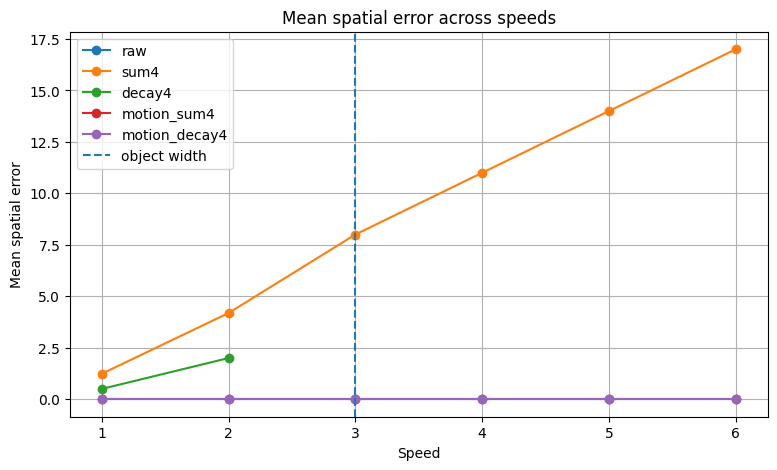

In [299]:
plot_df = speed_sweep_df.dropna(subset=["mean_spatial_error"])

plt.figure(figsize=(9, 5))

for method in methods:
    method_df = plot_df[plot_df["method"] == method]

    plt.plot(
        method_df["speed"],
        method_df["mean_spatial_error"],
        marker="o",
        label=method,
    )

plt.axvline(object_width, linestyle="--", label="object width")
plt.title("Mean spatial error across speeds")
plt.xlabel("Speed")
plt.ylabel("Mean spatial error")
plt.legend()
plt.grid(True)
plt.show()


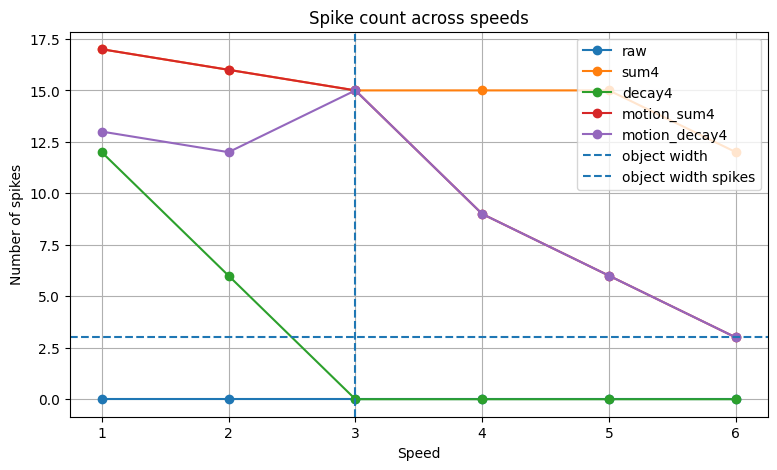

In [300]:
plt.figure(figsize=(9, 5))

for method in methods:
    method_df = speed_sweep_df[speed_sweep_df["method"] == method]

    plt.plot(
        method_df["speed"],
        method_df["num_spikes"],
        marker="o",
        label=method,
    )

plt.axvline(object_width, linestyle="--", label="object width")
plt.axhline(object_width, linestyle="--", label="object width spikes")
plt.title("Spike count across speeds")
plt.xlabel("Speed")
plt.ylabel("Number of spikes")
plt.legend()
plt.grid(True)
plt.show()


Want to improve successful shape detection


In [323]:
speed = 4

frames = lu.make_moving_1d_object(
    length=24,
    object_width=3,
    steps=8,
    speed=speed,
    intensity=0.30,
)

methods_to_inputs = {
    "raw": frames,
    "sum4": lu.apply_frame_buffer(frames, buffer_size=4),
    "decay4": lu.apply_decay_frame_buffer(frames, buffer_size=4, decay=0.9),
    "motion_sum4": lu.apply_motion_compensated_buffer(
        frames,
        buffer_size=4,
        assumed_speed=speed,
        decay=None,
    ),
    "motion_decay4": lu.apply_motion_compensated_buffer(
        frames,
        buffer_size=4,
        assumed_speed=speed,
        decay=0.9,
    ),
}

for method_name, input_frames in methods_to_inputs.items():
    spk_rec, mem_rec = lu.run_lif_layer(input_frames, beta=0.9)

    shape_summary = lu.summarize_frame_shape_recovery(
        frames,
        spk_rec,
        method_name,
    )

    print(method_name)
    print("max_frame_coverage:", shape_summary["max_frame_coverage"])
    print("frame_shape_success:", shape_summary["frame_shape_success"])
    print()


raw
max_frame_coverage: 0.0
frame_shape_success: False

sum4
max_frame_coverage: 0.0
frame_shape_success: False

decay4
max_frame_coverage: 0.0
frame_shape_success: False

motion_sum4
max_frame_coverage: 1.0
frame_shape_success: True

motion_decay4
max_frame_coverage: 1.0
frame_shape_success: True



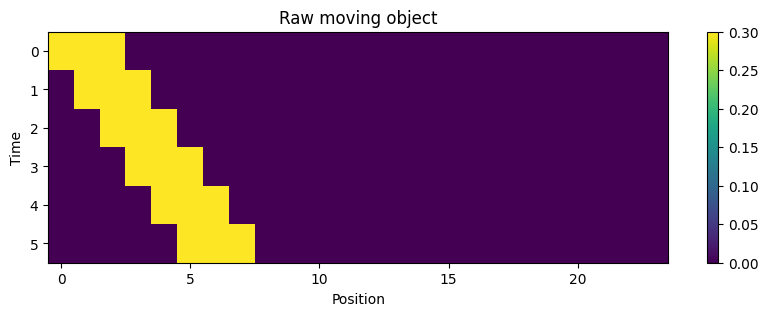

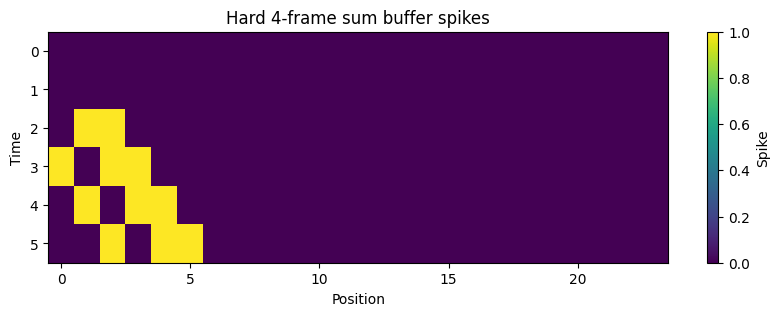

In [348]:
speed = 1

frames = lu.make_moving_1d_object(
    length=24,
    
    object_width=3,
    steps=6,
    speed=speed,
    intensity=0.3,
)

buffered_frames = lu.apply_frame_buffer(frames, buffer_size=4)



spk_raw, mem_raw = lu.run_lif_layer(frames, beta=0.9)
spk_buf, mem_buf = lu.run_lif_layer(buffered_frames, beta=0.9)


plt.figure(figsize=(10, 3))
plt.imshow(frames, aspect="auto")
plt.title("Raw moving object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()

lu.plot_spikes(spk_buf, "Hard 4-frame sum buffer spikes")





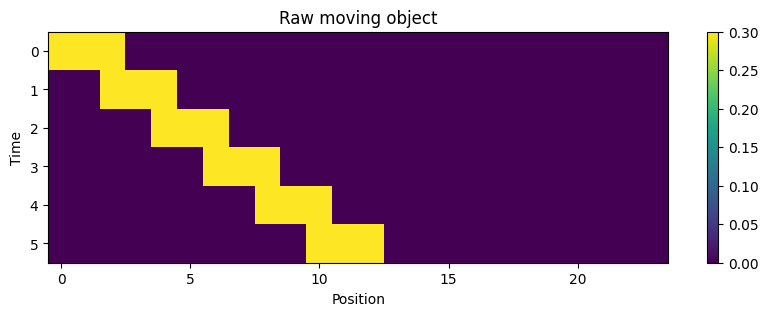

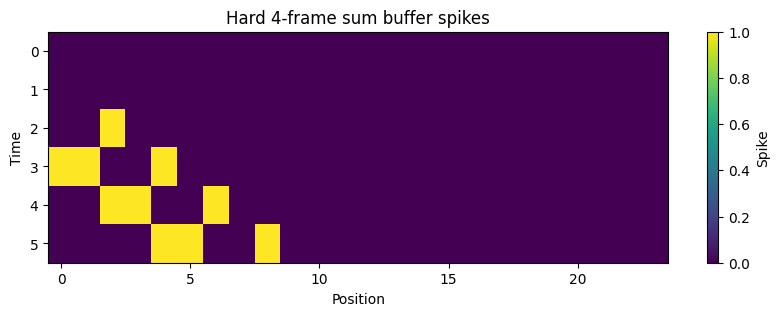

In [347]:
speed = 2

frames = lu.make_moving_1d_object(
    length=24,
    object_width=3,
    steps=6,
    speed=speed,
    intensity=0.3,
)

buffered_frames = lu.apply_frame_buffer(frames, buffer_size=4)
buffered_frames_decay = lu.apply_decay_frame_buffer(
    frames,
    buffer_size=4,
    decay=0.9,
)



spk_raw, mem_raw = lu.run_lif_layer(frames, beta=0.9)
spk_buf, mem_buf = lu.run_lif_layer(buffered_frames, beta=0.9)
plt.figure(figsize=(10, 3))
plt.imshow(frames, aspect="auto")
plt.title("Raw moving object")
plt.xlabel("Position")
plt.ylabel("Time")
plt.colorbar()
plt.show()


lu.plot_spikes(spk_buf, "Hard 4-frame sum buffer spikes")

